<a href="https://colab.research.google.com/github/klholmes1728-a11y/ores5160-2026/blob/main/week12_Visualizations_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2015_20260309.csv")

# Clean currency columns
df["Total Charges"] = df["Total Charges"].replace('[\$,]', '', regex=True).astype(float)
df["Total Costs"] = df["Total Costs"].replace('[\$,]', '', regex=True).astype(float)

# Clean Length of Stay
df["Length of Stay"] = df["Length of Stay"].replace('120 +', '120')
df["Length of Stay"] = df["Length of Stay"].astype(int)

# Drop duplicates
df = df.drop_duplicates()

<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_20075/4291940439.py:6: SyntaxWarning: invalid escape sequence '\$'
  df["Total Charges"] = df["Total Charges"].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_20075/4291940439.py:7: SyntaxWarning: invalid escape sequence '\$'
  df["Total Costs"] = df["Total Costs"].replace('[\$,]', '', regex=True).astype(float)


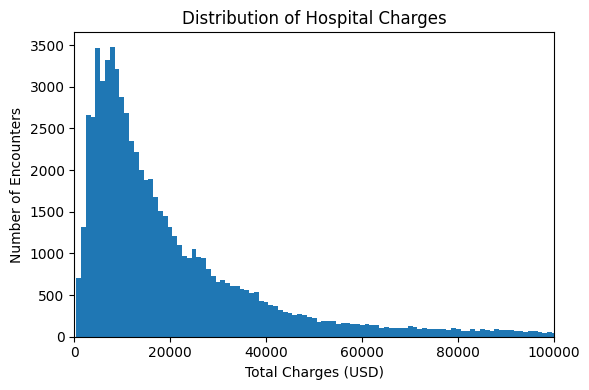

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Total Charges"], bins='auto')
plt.xlabel("Total Charges (USD)")
plt.ylabel("Number of Encounters")
plt.title("Distribution of Hospital Charges")
plt.xlim(0, 100000)
plt.tight_layout()
plt.show()

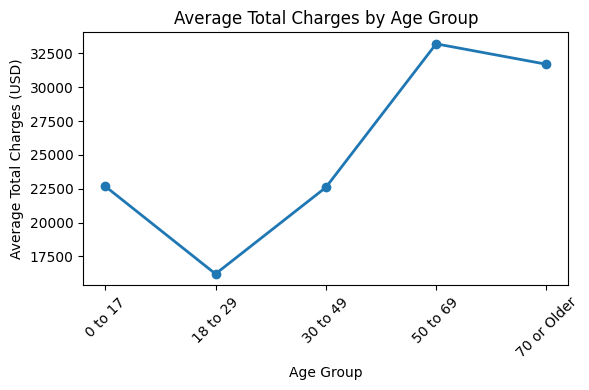

In [ ]:
avg_charges = (
    df.groupby("Age Group")["Total Charges"]
    .mean()
    .sort_index()   # ensures logical order
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(avg_charges["Age Group"], avg_charges["Total Charges"], marker='o', linewidth=2)

plt.xlabel("Age Group")
plt.ylabel("Average Total Charges (USD)")
plt.title("Average Total Charges by Age Group")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Health Service Area', 'Hospital County',
       'Operating Certificate Number', 'Facility Id', 'Facility Name',
       'Age Group', 'Zip Code - 3 digits', 'Gender', 'Race', 'Ethnicity',
       'Length of Stay', 'Type of Admission', 'Patient Disposition',
       'Discharge Year', 'CCS Diagnosis Code', 'CCS Diagnosis Description',
       'CCS Procedure Code', 'CCS Procedure Description', 'APR DRG Code',
       'APR DRG Description', 'APR MDC Code', 'APR MDC Description',
       'APR Severity of Illness Code', 'APR Severity of Illness Description',
       'APR Risk of Mortality', 'APR Medical Surgical Description',
       'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3',
       'Birth Weight', 'Abortion Edit Indicator',
       'Emergency Department Indicator', 'Total Charges', 'Total Costs'],
      dtype='object')

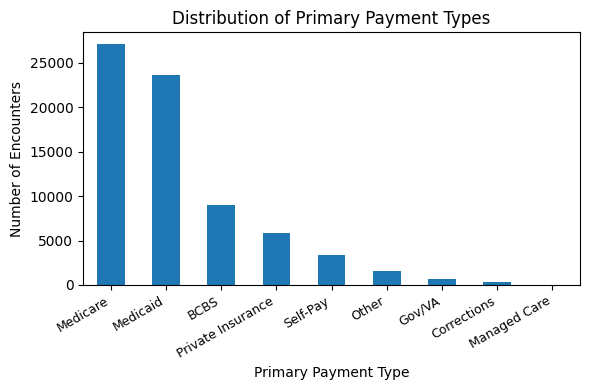

In [31]:
payment_counts = df["Payment Typology 1"].value_counts()
payment_counts.index = [
    label.replace("Blue Cross/Blue Shield", "BCBS")
         .replace("Private Health Insurance", "Private Insurance")
         .replace("Miscellaneous/Other", "Other")
         .replace("Federal/State/Local/VA", "Gov/VA")
         .replace("Department of Corrections", "Corrections")
         .replace("Managed Care, Unspecified", "Managed Care")
    for label in payment_counts.index
]
plt.figure(figsize=(6,4))
payment_counts.plot(kind='bar')

plt.xlabel("Primary Payment Type")
plt.ylabel("Number of Encounters")
plt.title("Distribution of Primary Payment Types")


plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()